# B1 — Analyse Exploratoire du Dataset BookSum
**Personne B** | Phase 1 : Données

> **Input :** `donnees_propres.json` produit par Personne A  
> **Output :** Statistiques + graphiques + recommandations pour le choix du tokenizer

In [2]:
!pip install pandas matplotlib seaborn

  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 796.8 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.2 MB 817.9 kB/s eta 0:00:10
   ----- ---------------------------------- 1.0/8.2 MB 898.8 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.2 MB 971.8 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ----------------

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ On charge uniquement le fichier produit par Personne A
# Pas besoin de re-télécharger BookSum
with open("donnees_propres.json", "r") as f:
    donnees = json.load(f)

print(f"Nombre d'exemples chargés : {len(donnees)}")
print(f"Clés disponibles : {list(donnees[0].keys())}")
print(f"\nAperçu exemple 0 :")
print(f"  nb_chunks : {donnees[0]['nb_chunks']}")
print(f"  résumé    : {donnees[0]['resume'][:150]}...")

Nombre d'exemples chargés : 100
Clés disponibles : ['chunks', 'resume', 'nb_chunks']

Aperçu exemple 0 :
  nb_chunks : 14
  résumé    : Before any characters appear, the time and geography are made clear. Though it is the last war that England and France waged for a country that neithe...


## 1. Distribution des longueurs de textes

In [5]:
# Calculer les longueurs à partir des chunks (pas besoin du dataset brut)
longueurs_texte  = [sum(len(c.split()) for c in d["chunks"]) for d in donnees]
longueurs_resume = [len(d["resume"].split()) for d in donnees]
nb_chunks        = [d["nb_chunks"] for d in donnees]

df = pd.DataFrame({
    "nb_mots_texte":  longueurs_texte,
    "nb_mots_resume": longueurs_resume,
    "nb_chunks":      nb_chunks
})

print("=== Statistiques générales ===")
print(df.describe().round(1))

=== Statistiques générales ===
       nb_mots_texte  nb_mots_resume  nb_chunks
count          100.0           100.0      100.0
mean          5425.2           353.5       11.1
std           1515.2           215.7        3.0
min           3204.0            86.0        7.0
25%           4365.0           188.8        9.0
50%           5506.0           319.0       11.0
75%           5940.0           476.5       12.0
max           9944.0           959.0       20.0


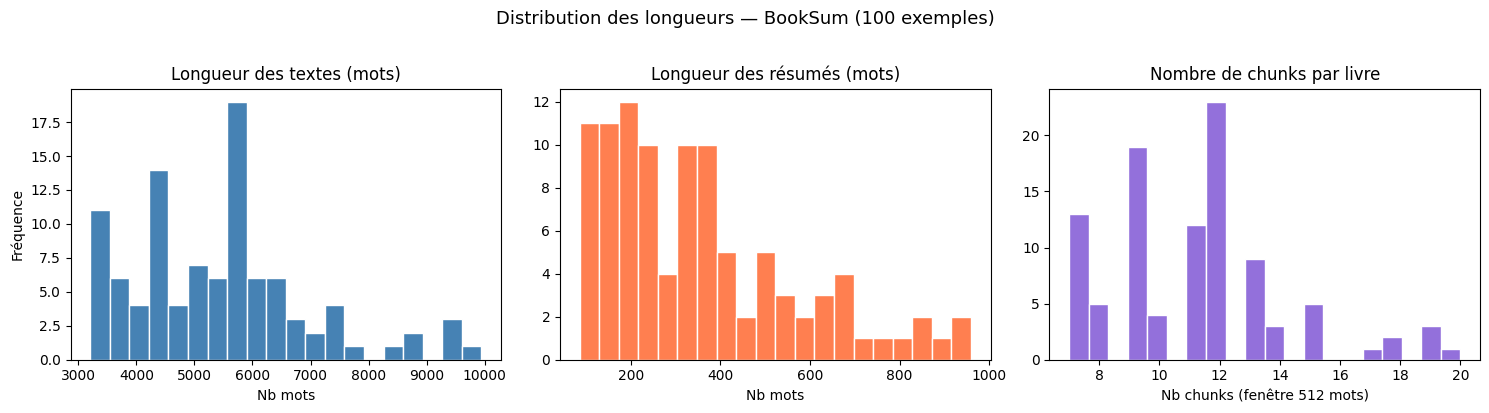

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(longueurs_texte, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Longueur des textes (mots)")
axes[0].set_xlabel("Nb mots")
axes[0].set_ylabel("Fréquence")

axes[1].hist(longueurs_resume, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Longueur des résumés (mots)")
axes[1].set_xlabel("Nb mots")

axes[2].hist(nb_chunks, bins=20, color="mediumpurple", edgecolor="white")
axes[2].set_title("Nombre de chunks par livre")
axes[2].set_xlabel("Nb chunks (fenêtre 512 mots)")

plt.suptitle("Distribution des longueurs — BookSum (100 exemples)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Ratio de compression texte → résumé

Ratio moyen  : 20.3x
Ratio médian : 17.9x
Ratio min    : 5.2x
Ratio max    : 49.1x


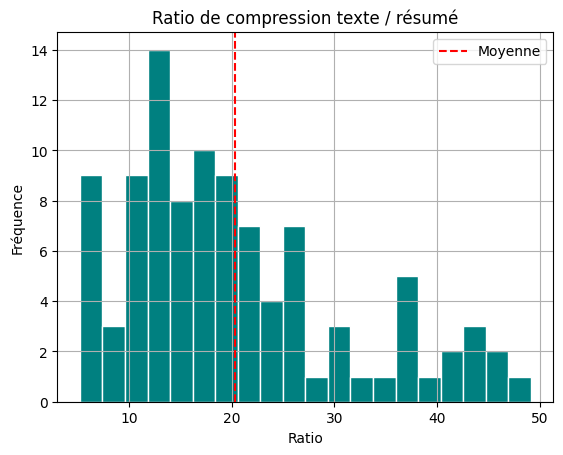

In [7]:
df["ratio_compression"] = df["nb_mots_texte"] / df["nb_mots_resume"]

print(f"Ratio moyen  : {df['ratio_compression'].mean():.1f}x")
print(f"Ratio médian : {df['ratio_compression'].median():.1f}x")
print(f"Ratio min    : {df['ratio_compression'].min():.1f}x")
print(f"Ratio max    : {df['ratio_compression'].max():.1f}x")

df["ratio_compression"].hist(bins=20, color="teal", edgecolor="white")
plt.title("Ratio de compression texte / résumé")
plt.xlabel("Ratio")
plt.ylabel("Fréquence")
plt.axvline(df['ratio_compression'].mean(), color='red', linestyle='--', label='Moyenne')
plt.legend()
plt.show()

## 3. Analyse des chunks

In [8]:
print("=== Analyse des chunks ===")
print(f"Nb chunks moyen par livre : {df['nb_chunks'].mean():.1f}")
print(f"Nb chunks médian          : {df['nb_chunks'].median():.1f}")
print(f"Min / Max                 : {df['nb_chunks'].min()} / {df['nb_chunks'].max()}")

# Livres avec beaucoup de chunks (coûteux en inférence Map-Reduce)
seuil = 10
nb_longs = (df["nb_chunks"] > seuil).sum()
print(f"\nLivres avec plus de {seuil} chunks : {nb_longs} ({100*nb_longs//len(df)}%)")
print("→ Ces livres seront les plus coûteux dans le pipeline Map-Reduce")

=== Analyse des chunks ===
Nb chunks moyen par livre : 11.1
Nb chunks médian          : 11.0
Min / Max                 : 7 / 20

Livres avec plus de 10 chunks : 59 (59%)
→ Ces livres seront les plus coûteux dans le pipeline Map-Reduce


## 4. Conclusions & recommandations pour B2

| Métrique | Valeur |
|---|---|
| Nb mots moyen (texte) | *(à remplir après exécution)* |
| Nb mots moyen (résumé) | *(à remplir)* |
| Ratio compression moyen | *(à remplir)* |
| Nb chunks moyen | *(à remplir)* |

### Recommandations pour le choix du tokenizer (B2)
- Les textes sont **très longs** → un tokenizer avec un **grand vocab** réduit le nombre de tokens et limite la troncature
- Les résumés font en moyenne ~X mots → `max_length=128` côté labels est **suffisant**
- Les chunks de 512 mots de Personne A génèrent environ Y tokens → tester `max_length=512` et `1024`
- Tâche abstractive (ratio élevé) → privilégier un tokenizer entraîné sur des corpus **littéraires/anglais**
- **Candidats à benchmarker :** T5 (SentencePiece), BART (BPE), PEGASUS (BPE)